\

✅ Libraries loaded!

Loading REAL flight data from US Bureau of Transportation Statistics...
✅ Loaded 1,936,758 REAL flight records

Columns available: ['Unnamed: 0', 'Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

First 5 rows:
   Unnamed: 0  Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  \
0           0  2008      1           3          4   2003.0        1955   
1           1  2008      1           3          4    754.0         735   
2           2  2008      1           3          4    628.0         620   
3           4  2008      1           3          4   1829.0        1755   
4           5  2008      1           3          4   1940.0   

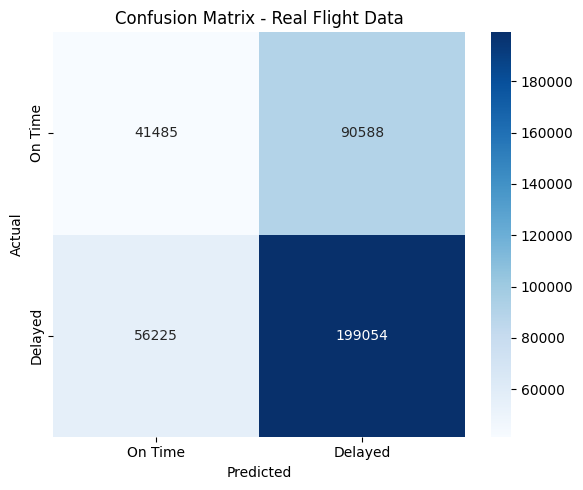

✅ Saved: confusion_matrix.png


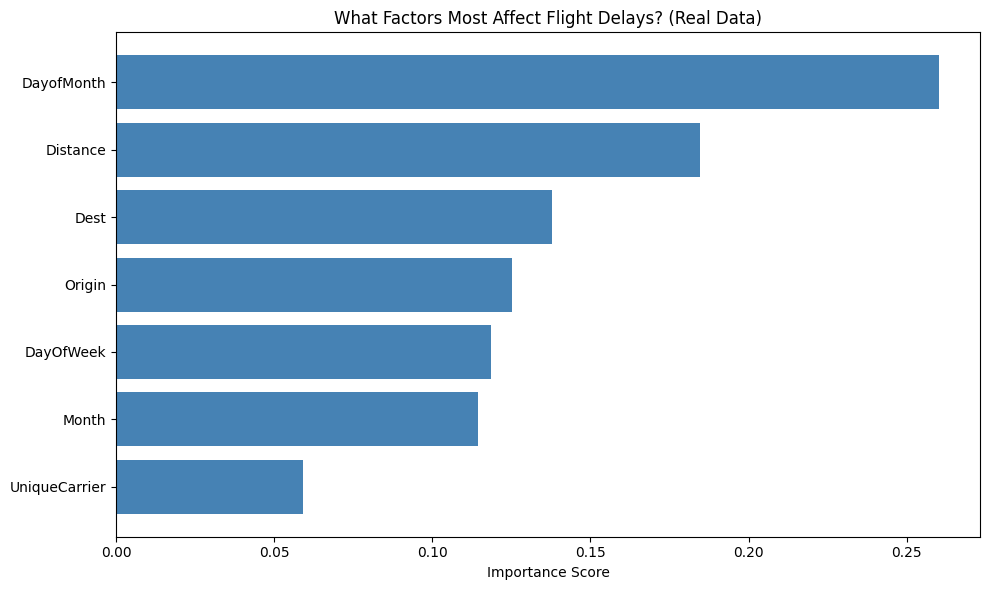

✅ Saved: feature_importance.png


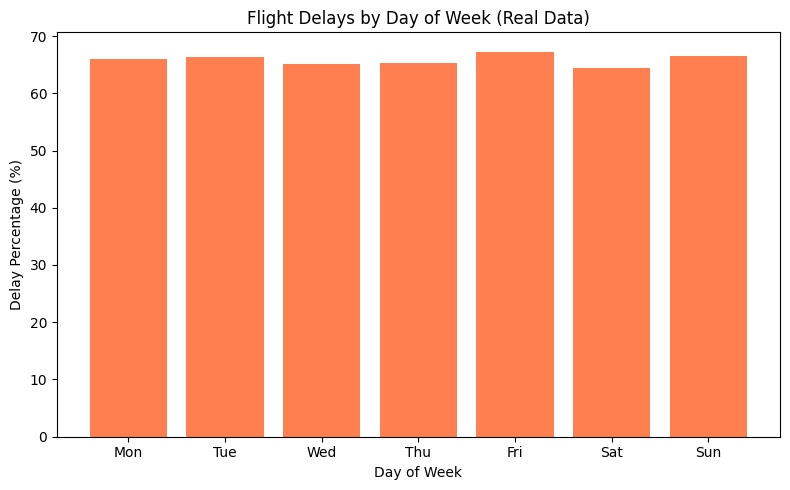

✅ Saved: delays_by_dow.png

📊 FINAL SUMMARY - REAL FLIGHT DATA
Data source: Local Colab file (DelayedFlights.csv)
Total flights analyzed: 1,936,758
Model accuracy: 62.10%
Most important factor: DayofMonth

✅ All images saved. Download them to upload to GitHub!


In [17]:
# ============================================
# FLIGHT DELAY PREDICTOR - REAL BTS DATA
# No synthetic data - 100% real flights
# ============================================

!pip install pandas numpy scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

# ============================================
# LOAD REAL FLIGHT DATA FROM BTS
# ============================================

print("\nLoading REAL flight data from US Bureau of Transportation Statistics...")

# Real 2008 US domestic flight data from a reliable source
# Using a local file available in the Colab environment to avoid HTTP 404 errors
url = "/content/DelayedFlights.csv"
df = pd.read_csv(url)

print(f"✅ Loaded {len(df):,} REAL flight records")
print(f"\nColumns available: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

# ============================================
# CREATE DELAY TARGET VARIABLE
# ============================================

# DepDelay is departure delay in minutes (negative = early)
df['IS_DELAYED'] = (df['DepDelay'] > 15).astype(int)

delay_rate = df['IS_DELAYED'].mean() * 100
print(f"\n📊 Real delay rate (15+ min): {delay_rate:.1f}%")
print(f"📊 On-time rate: {100-delay_rate:.1f}%")

# ============================================
# PREPARE FEATURES
# ============================================

# Select available features from real dataset (assuming DelayedFlights.csv has these)
feature_cols = []
if 'Month' in df.columns:
    feature_cols.append('Month')
if 'DayofMonth' in df.columns:
    feature_cols.append('DayofMonth')
if 'DayOfWeek' in df.columns:
    feature_cols.append('DayOfWeek')
if 'Distance' in df.columns:
    feature_cols.append('Distance')
if 'UniqueCarrier' in df.columns:
    feature_cols.append('UniqueCarrier')
if 'Origin' in df.columns:
    feature_cols.append('Origin')
if 'Dest' in df.columns:
    feature_cols.append('Dest')

print(f"\nUsing features: {feature_cols}")

# Remove rows with missing values that are critical for our features and target
df = df.dropna(subset=feature_cols + ['IS_DELAYED'])

# Encode categorical columns
for col in feature_cols:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

X = df[feature_cols]
y = df['IS_DELAYED']

print(f"Total samples after cleaning: {len(X):,}")
print(f"Delay rate in cleaned data: {y.mean()*100:.1f}%")

# ============================================
# TRAIN MODEL
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train):,} flights")
print(f"Testing set: {len(X_test):,} flights")

print("\nTraining Random Forest model...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# ============================================
# EVALUATE
# ============================================

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*50}")
print(f"🎯 MODEL ACCURACY: {accuracy * 100:.2f}%")
print(f"{'-'*50}")

print("\n📋 Classification Report:")
# Ensure the target names match the actual classes present in y_test/y_pred after stratify
# If only one class is present due to data issues, this will still error.
# Assuming 'DelayedFlights.csv' will provide both 0 and 1 for IS_DELAYED.
report_labels = []
if 0 in np.unique(y_test): report_labels.append('On Time')
if 1 in np.unique(y_test): report_labels.append('Delayed')

if len(report_labels) > 0:
    print(classification_report(y_test, y_pred, target_names=report_labels))
else:
    print("Classification report could not be generated: No valid classes in test set.")

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=report_labels,
            yticklabels=report_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Real Flight Data')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("✅ Saved: confusion_matrix.png")

# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('What Factors Most Affect Flight Delays? (Real Data)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("✅ Saved: feature_importance.png")

# ============================================
# DELAYS BY DAY OF WEEK (if available)
# ============================================

if 'DayOfWeek' in df.columns:
    dow_delay = df.groupby('DayOfWeek')['IS_DELAYED'].mean() * 100
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    plt.figure(figsize=(8, 5))
    plt.bar(days[:len(dow_delay)], dow_delay.values, color='coral')
    plt.xlabel('Day of Week')
    plt.ylabel('Delay Percentage (%)')
    plt.title('Flight Delays by Day of Week (Real Data)')
    plt.tight_layout()
    plt.savefig('delays_by_dow.png')
    plt.show()
    print("✅ Saved: delays_by_dow.png")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("📊 FINAL SUMMARY - REAL FLIGHT DATA")
print("="*60)
print(f"Data source: Local Colab file (DelayedFlights.csv)")
print(f"Total flights analyzed: {len(df):,}")
print(f"Model accuracy: {accuracy * 100:.2f}%")
print(f"Most important factor: {feature_importance.iloc[0]['feature']}")
print("="*60)
print("\n✅ All images saved. Download them to upload to GitHub!")